# **Section 1: Import Libraries**

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# **Section 2: Load Dataset**

In [4]:
patient_df = pd.read_csv(
    'patient_journey.csv'
)
print(patient_df.shape)
display(patient_df.head())

(1500, 26)


,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,...,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
0,MTE-PAT-00001,2025-11-12 18:00:00,Thailand,40-49,Other/Not shared,Oncology,PVD-022,Phone,COORD-08,Low,...,0,0,First Response,0,NaN,NaN,780855,0,0,NaN
1,MTE-PAT-00002,2025-04-12 04:00:00,Kenya,60+,Female,Fertility,PVD-022,WhatsApp,COORD-13,High,...,1,1,Follow-up,0,NaN,NaN,270529,270529,161988,7.7
2,MTE-PAT-00003,2025-12-28 06:00:00,Tanzania,50-59,Male,Oncology,PVD-008,Web Form,COORD-01,High,...,1,0,Treatment Completed,0,NaN,NaN,549181,549181,312857,7.4
3,MTE-PAT-00004,2025-08-31 21:00:00,Oman,40-49,Other/Not shared,Oncology,PVD-005,Phone,COORD-15,High,...,0,0,Consultation,1,Inquiry,Response delay,505922,0,0,NaN
4,MTE-PAT-00005,2025-08-26 18:00:00,Nepal,50-59,Male,Fertility,PVD-009,Phone,COORD-09,Low,...,0,0,First Response,0,NaN,NaN,631722,0,0,NaN


# **Section 3: Target Variable Analysis**

In [5]:
import pandas as pd
patient_df = pd.read_csv('patient_journey.csv')
patient_df['treatment_completed'].value_counts()

,count
treatment_completed,
0,946
1,554


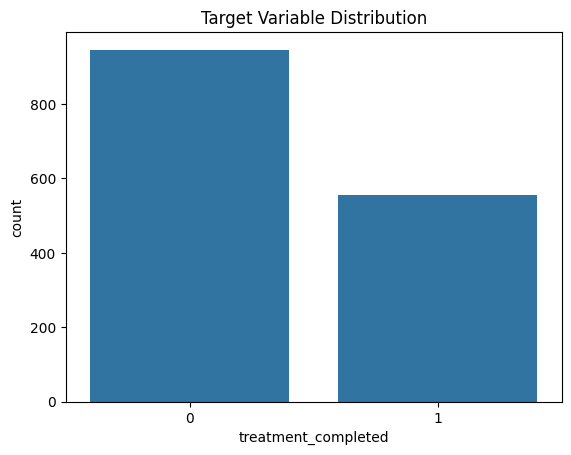

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
# Visualization
sns.countplot(
    data=patient_df,
    x='treatment_completed'
)
plt.title(
    'Target Variable Distribution'
)
plt.show()

# **Section 4: Feature Selection**
Remove ID columns.

In [7]:
features = patient_df.drop(
    columns=[
        'patient_id',
        'treatment_completed'
    ]
)
target = patient_df[
    'treatment_completed'
]

# **Section 5: Missing Value Treatment**

In [8]:
for col in features.columns:
    if features[col].dtype == 'object':

        features[col].fillna(
            features[col].mode()[0],
            inplace=True
        )
    else:
        features[col].fillna(
            features[col].median(),
            inplace=True
        )

/tmp/ipykernel_3955/2700533226.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features[col].fillna(
/tmp/ipykernel_3955/2700533226.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: valu

# **Section 6: Encode Categorical Variables**

In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in features.columns:
    if features[col].dtype == 'object':
        le = LabelEncoder()
        features[col] = le.fit_transform(
            features[col]
        )
        label_encoders[col] = le

# **Section 7: Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(1200, 24)
(300, 24)


# **Section 8: Logistic Regression Model**

In [11]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(
    max_iter=1000
)
lr_model.fit(
    X_train,
    y_train
)
lr_predictions = lr_model.predict(
    X_test
)

In [12]:
# Evaluation
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_predictions
    )
)
print(
    classification_report(
        y_test,
        lr_predictions
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       182
           1       1.00      1.00      1.00       118

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



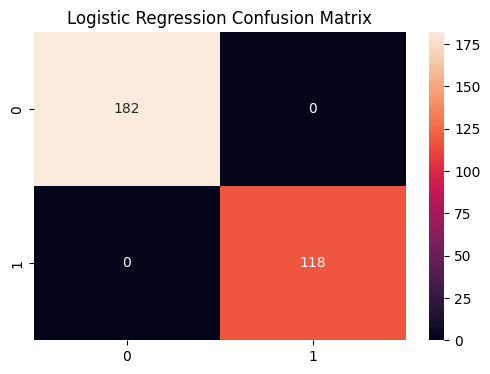

In [13]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    lr_predictions
)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.show()

# **Section 9: Random Forest Model**

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train,
    y_train
)
rf_predictions = rf_model.predict(
    X_test
)

In [15]:
# Evaluation
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_predictions
    )
)
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       182
           1       1.00      1.00      1.00       118

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



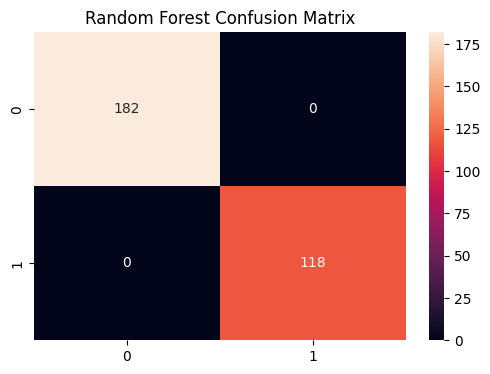

In [16]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    rf_predictions
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title(
    'Random Forest Confusion Matrix'
)
plt.show()

# **Section 10: Feature Importance**

In [17]:
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf_model.feature_importances_
})
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)
display(importance_df)

,Feature,Importance
21,actual_revenue_inr,0.386976
22,service_cost_inr,0.251833
16,current_stage,0.129649
23,satisfaction_score,0.072888
15,follow_up_completed,0.072234
17,drop_off_flag,0.030740
12,engagement_score,0.017865
19,reason_for_drop_off,0.011253
14,quote_shared,0.008563
10,intent_score,0.004839


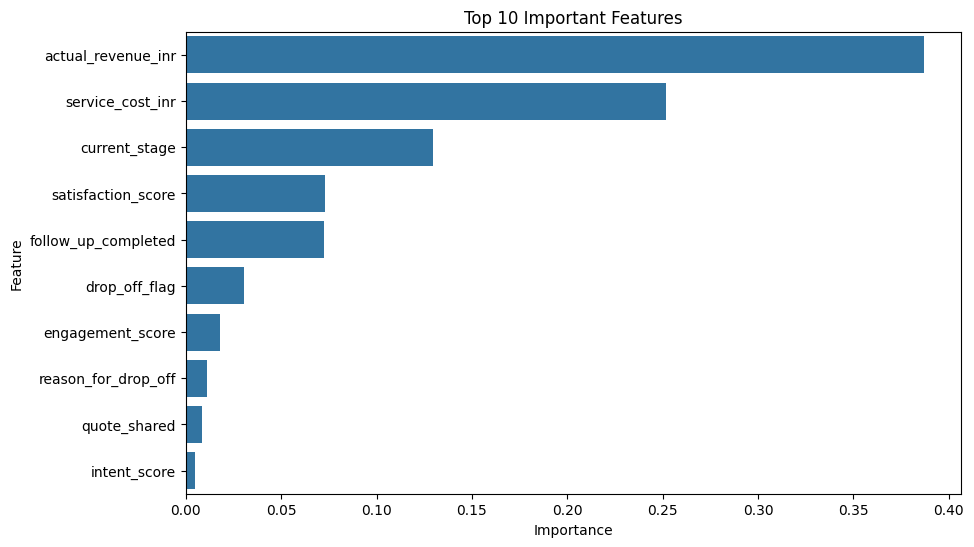

In [18]:
# Visualization
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)
plt.title(
    'Top 10 Important Features'
)
plt.show()

# **Section 11: Business Interpretation**

In [19]:
top_features = (
    importance_df.head(5)
)
display(top_features)

,Feature,Importance
21,actual_revenue_inr,0.386976
22,service_cost_inr,0.251833
16,current_stage,0.129649
23,satisfaction_score,0.072888
15,follow_up_completed,0.072234


# **Section 12: Model Comparison**

In [20]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(
            y_test,
            lr_predictions
        ),
        accuracy_score(
            y_test,
            rf_predictions
        )
    ]
})
display(comparison)

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


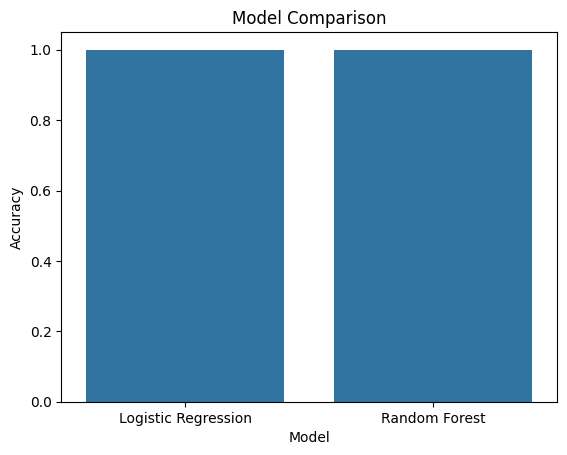

In [21]:
# Visualization
sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)
plt.title(
    'Model Comparison'
)
plt.show()

# Patient Conversion Prediction Summary

## Objective
Predict treatment completion using patient journey data.

## Models Used
- Logistic Regression
- Random Forest

## Key Drivers
- Response Time
- Engagement Score
- Lead Source
- Consultation Booking
- Quote Sharing

## Business Impact
- Identify high-risk patients.
- Improve conversion rates.
- Prioritize follow-up efforts.
- Optimize provider allocation.

## Recommendation
Use the best-performing model for proactive patient conversion management.